In [4]:
import pandas as pd
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.preprocessing import LabelEncoder
#from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.ticker as ticker


In [5]:
#### Activar segun quien trabaje 
#Marco
Filepath = "C:/Users/asus/OneDrive/Documentos/semestres uniandes/Clases 2025-1/Tesis IIND/Solo sector salud/Base analisis exploratorio.csv"
#Paula
#Filepath= "C:/Users/paula/OneDrive/Documentos/10 Semestre/Tesis/base con categorias reducidas2.csv"
df=pd.read_csv(Filepath)
df

,nombre entidad,nit entidad,departamento,ciudad,orden,rama,entidad centralizada,estado contrato,codigo de categoria principal,tipo de contrato,...,precio base,nombre de la unidad de contratación,departamento proveedor,ciudad proveedor,tiempo duracion (dias),duracion_proceso_dias,año_publicacion,porcentaje_pagado,año_publicacion_fase,Adicion
0,Otros,Otros,Meta,Villavicencio,Territorial,Ejecutivo,Centralizada,En ejecución,V1.85101600,Prestación de servicios,...,8.273630e+06,Otros,Meta,Otros,38.0,39.0,2024,25-50%,2024,0
1,SUBRED INTEGRADA DE SERVICIO DE SALUD CENTRO O...,900959051,Distrito Capital de Bogotá,Bogotá,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111600,Prestación de servicios,...,2.908492e+07,CONTRATACION OPS 2020,Distrito Capital de Bogotá,Bogotá,48.0,53.0,2020,0-25%,2020,1
2,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARI...,890399011,Valle del Cauca,Cali,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111500,Prestación de servicios,...,5.907958e+07,SECRETARIA DISTRITAL DE SALUD DE CALI,Valle del Cauca,Cali,50.0,57.0,2020,0-25%,2020,0
3,SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E...,900971006,Distrito Capital de Bogotá,Bogotá,Territorial,Corporación Autónoma,Descentralizada,Activo,V1.85101600,Prestación de servicios,...,3.440880e+07,Otros,Distrito Capital de Bogotá,No Definido,88.0,90.0,2018,0-25%,2018,1
4,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,Otros,Prestación de servicios,...,7.000000e+07,Grupo de contratación SECOP II,Magdalena,Santa Marta,57.0,60.0,2022,0-25%,2022,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141367,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,...,6.305000e+07,Grupo de contratación SECOP II,Magdalena,Santa Marta,150.0,150.0,2022,0-25%,2022,0
141368,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,...,9.000000e+06,Grupo de contratación SECOP II,Magdalena,Santa Marta,145.0,150.0,2022,0-25%,2022,0
141369,Otros,Otros,Casanare,Yopal,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111701,Prestación de servicios,...,1.800000e+06,Otros,Casanare,Otros,30.0,30.0,2023,0-25%,2023,0
141370,Otros,899999239,Nariño,No Definido,Nacional,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,...,1.568828e+07,Otros,Nariño,Otros,175.0,173.0,2024,0-25%,2024,0


In [6]:
df.columns

Index(['nombre entidad', 'nit entidad', 'departamento', 'ciudad', 'orden',
       'rama', 'entidad centralizada', 'estado contrato',
       'codigo de categoria principal', 'tipo de contrato',
       'modalidad de contratacion', 'justificacion modalidad de contratacion',
       'fecha de firma', 'condiciones de entrega', 'es pyme', 'liquidación',
       'origen de los recursos', 'destino gasto', 'valor del contrato',
       'valor pendiente de pago', 'valor pendiente de ejecucion',
       'estado bpin', 'anno bpin', 'el contrato puede ser prorrogado', 'fase',
       'fecha de ultima publicación', 'fecha de publicacion (fase seleccion)',
       'precio base', 'nombre de la unidad de contratación',
       'departamento proveedor', 'ciudad proveedor', 'tiempo duracion (dias)',
       'duracion_proceso_dias', 'año_publicacion', 'porcentaje_pagado',
       'año_publicacion_fase', 'Adicion'],
      dtype='object')

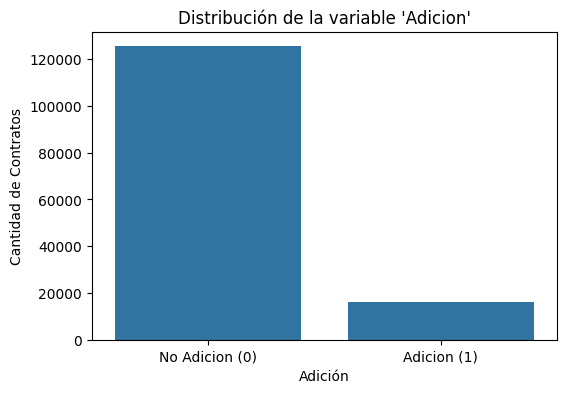

In [7]:
# Gráfico de barras para la distribución de "Adicion"
plt.figure(figsize=(6, 4))
sns.countplot(x="Adicion", data=df)
plt.title("Distribución de la variable 'Adicion'")
plt.xticks(ticks=[0, 1], labels=["No Adicion (0)", "Adicion (1)"])
plt.xlabel("Adición")
plt.ylabel("Cantidad de Contratos")
plt.show()


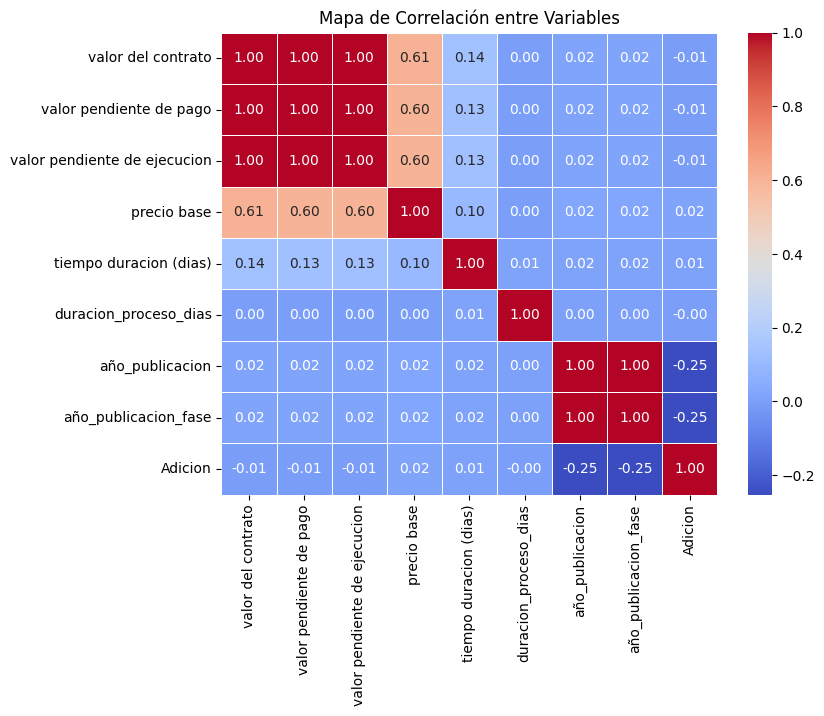

In [8]:
# --- 1. HEATMAP DE CORRELACIÓN ---
fig, ax = plt.subplots(figsize=(8, 6))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Mapa de Correlación entre Variables")
plt.show()

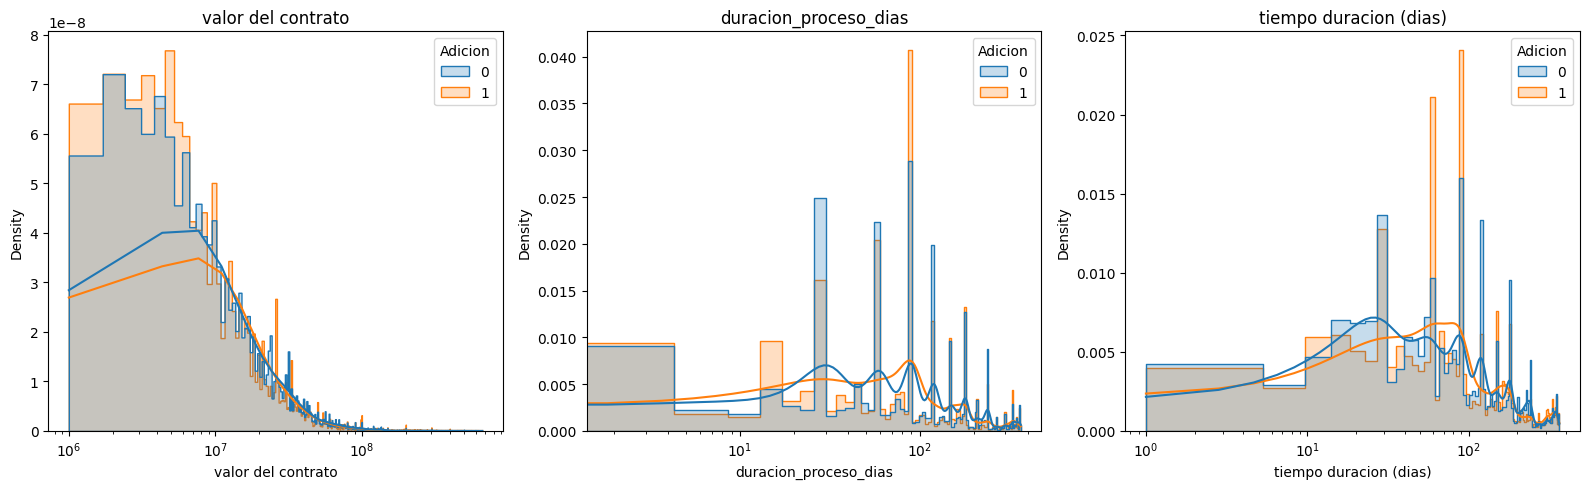

In [61]:
# Definir variables numéricas relevantes para analizar con "Adicion"
variables_numericas = ["valor del contrato", "duracion_proceso_dias", "tiempo duracion (dias)"]

# Filtrar valores extremos para mejorar la visualización (percentil 99)
df_filtered = df.copy()
for var in variables_numericas:
    upper_limit = np.percentile(df[var].dropna(), 99)
    df_filtered = df_filtered[df_filtered[var] <= upper_limit]

# Crear subgráficos con escala logarítmica en X para mejorar visibilidad
fig, axes = plt.subplots(1, len(variables_numericas), figsize=(16, 5))

for i, var in enumerate(variables_numericas):
    sns.histplot(df_filtered, x=var, hue="Adicion", element="step", kde=True, ax=axes[i], stat="density", common_norm=False)
    axes[i].set_title(var)
    axes[i].set_xscale("log")  # Aplicar escala logarítmica para mejor visibilidad

plt.tight_layout()
plt.show()



C:\Users\user\AppData\Local\Temp\ipykernel_15544\1851557174.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])  # Notación 10^#


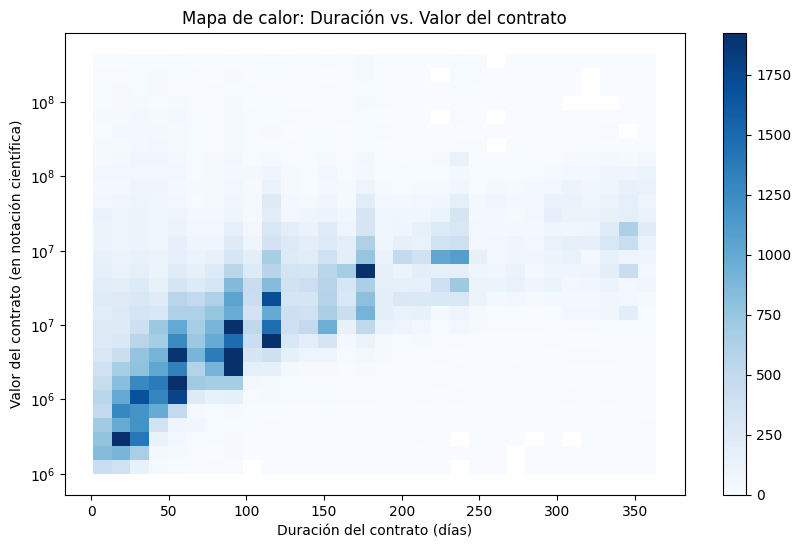

In [62]:
# Filtrar valores extremos para mejorar la visualización (percentil 99)
upper_limit_valor = np.percentile(df["valor del contrato"].dropna(), 99)
upper_limit_duracion = np.percentile(df["tiempo duracion (dias)"].dropna(), 99)
df_filtered = df[
    (df["valor del contrato"] <= upper_limit_valor) &
    (df["tiempo duracion (dias)"] <= upper_limit_duracion)
]

# --- Heatmap de conteo con escala logarítmica en el eje Y ---
plt.figure(figsize=(10, 6))
heatmap_data = df_filtered.copy()

# Aplicar log solo para visualización
heatmap_data["valor del contrato log"] = np.log10(heatmap_data["valor del contrato"])

# Crear heatmap
ax = sns.histplot(
    x="tiempo duracion (dias)",
    y="valor del contrato log",
    data=heatmap_data,
    bins=30,
    pmax=0.9,
    cmap="Blues",
    cbar=True
)

# Mejorar etiquetas del eje Y en notación científica 10^#
yticks = ax.get_yticks()
ax.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])  # Notación 10^#

plt.xlabel("Duración del contrato (días)")
plt.ylabel("Valor del contrato (en notación científica)")
plt.title("Mapa de calor: Duración vs. Valor del contrato")
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_15544\163520873.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
C:\Users\user\AppData\Local\Temp\ipykernel_15544\163520873.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])


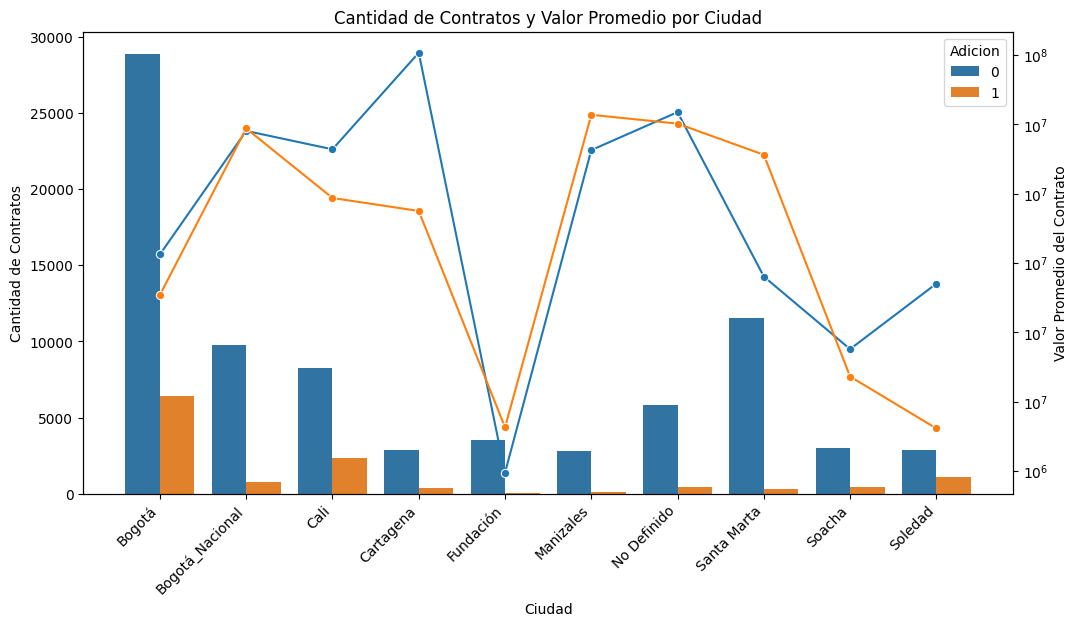

In [63]:
# Filtrar las 10 ciudades con más contratos
top_cities = df["ciudad"].value_counts().head(10).index
df_filtered = df[df["ciudad"].isin(top_cities)]

# Agrupar por ciudad y adición para obtener cantidad y valor promedio
df_grouped = df_filtered.groupby(["ciudad", "Adicion"]).agg(
    cantidad_contratos=("valor del contrato", "count"),
    valor_promedio=("valor del contrato", "mean")
).reset_index()

# --- Opción: Barras apiladas + Línea de tendencia con notación 10^x ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico de barras: Cantidad de contratos por ciudad y adición
sns.barplot(x="ciudad", y="cantidad_contratos", hue="Adicion", data=df_grouped, ax=ax1)
ax1.set_ylabel("Cantidad de Contratos")
ax1.set_xlabel("Ciudad")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.set_title("Cantidad de Contratos y Valor Promedio por Ciudad")

# Segundo eje para la línea de tendencia del valor promedio del contrato
ax2 = ax1.twinx()
sns.lineplot(x="ciudad", y=np.log10(df_grouped["valor_promedio"]), hue="Adicion", data=df_grouped, marker="o", ax=ax2, legend=False)
ax2.set_ylabel("Valor Promedio del Contrato")

# Ajustar etiquetas en notación científica 10^x
yticks = ax2.get_yticks()
ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])

plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_15544\2296921309.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
C:\Users\user\AppData\Local\Temp\ipykernel_15544\2296921309.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])


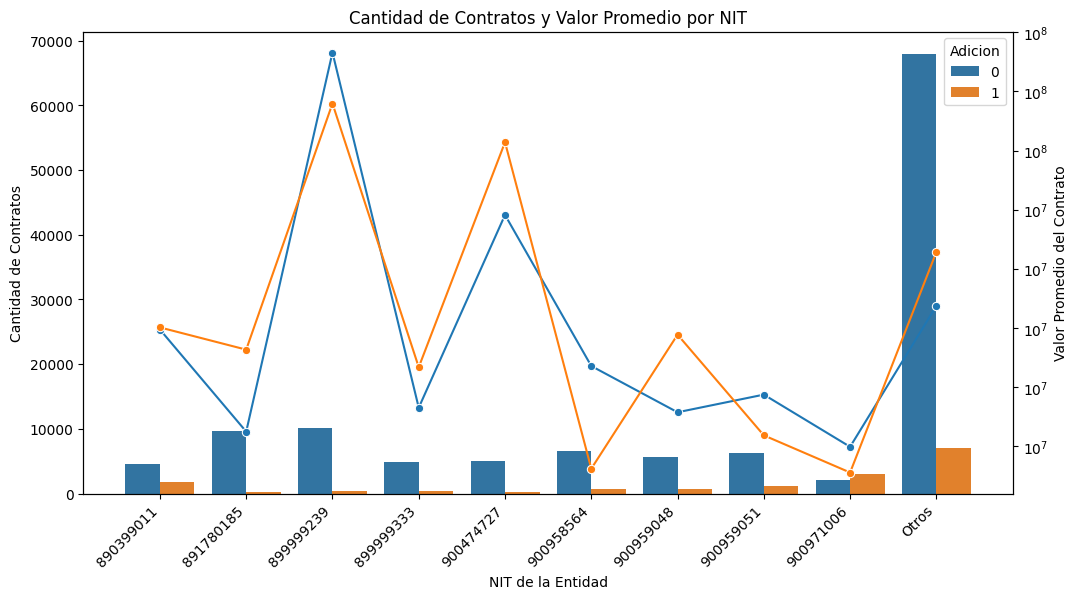

In [64]:

# Filtrar los 10 NIT con más contratos
top_nits = df["nit entidad"].value_counts().head(10).index
df_filtered = df[df["nit entidad"].isin(top_nits)]

# Agrupar por NIT y Adición para obtener cantidad y valor promedio
df_grouped = df_filtered.groupby(["nit entidad", "Adicion"]).agg(
    cantidad_contratos=("valor del contrato", "count"),
    valor_promedio=("valor del contrato", "mean")
).reset_index()

# --- Barras apiladas + Línea de tendencia con notación 10^x ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico de barras: Cantidad de contratos por NIT y Adición
sns.barplot(x="nit entidad", y="cantidad_contratos", hue="Adicion", data=df_grouped, ax=ax1)
ax1.set_ylabel("Cantidad de Contratos")
ax1.set_xlabel("NIT de la Entidad")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.set_title("Cantidad de Contratos y Valor Promedio por NIT")

# Segundo eje para la línea de tendencia del valor promedio del contrato
ax2 = ax1.twinx()
sns.lineplot(x="nit entidad", y=np.log10(df_grouped["valor_promedio"]), hue="Adicion", data=df_grouped, marker="o", ax=ax2, legend=False)
ax2.set_ylabel("Valor Promedio del Contrato")

# Ajustar etiquetas en notación científica 10^x
yticks = ax2.get_yticks()
ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])

plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_15544\3399802680.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
C:\Users\user\AppData\Local\Temp\ipykernel_15544\3399802680.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])


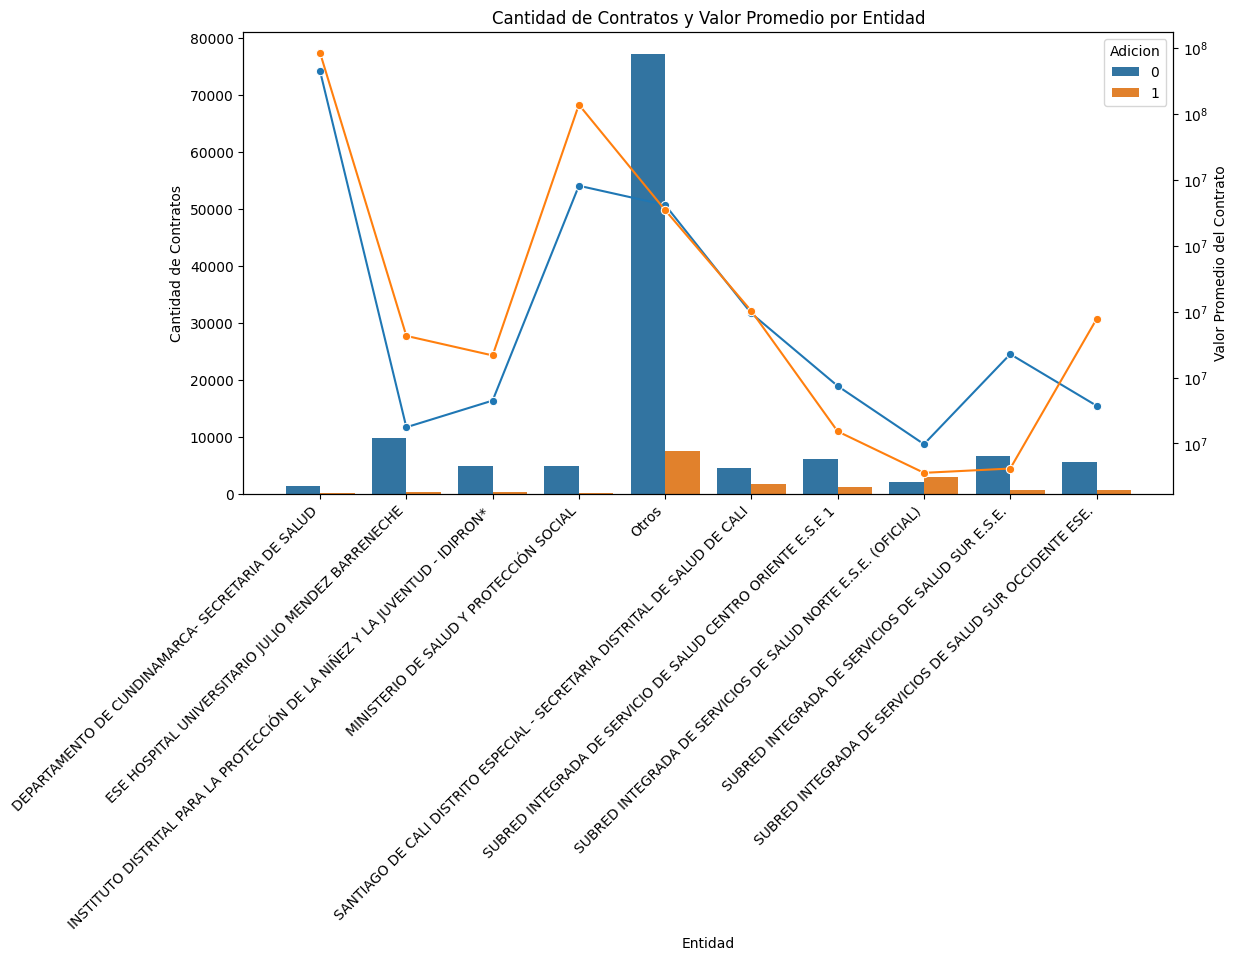

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filtrar las 10 entidades con más contratos
top_entidades = df["nombre entidad"].value_counts().head(10).index
df_filtered = df[df["nombre entidad"].isin(top_entidades)]

# Agrupar por entidad y adición para obtener cantidad y valor promedio
df_grouped = df_filtered.groupby(["nombre entidad", "Adicion"]).agg(
    cantidad_contratos=("valor del contrato", "count"),
    valor_promedio=("valor del contrato", "mean")
).reset_index()

# --- Barras apiladas + Línea de tendencia con notación 10^x ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico de barras: Cantidad de contratos por entidad y Adición
sns.barplot(x="nombre entidad", y="cantidad_contratos", hue="Adicion", data=df_grouped, ax=ax1)
ax1.set_ylabel("Cantidad de Contratos")
ax1.set_xlabel("Entidad")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.set_title("Cantidad de Contratos y Valor Promedio por Entidad")

# Segundo eje para la línea de tendencia del valor promedio del contrato
ax2 = ax1.twinx()
sns.lineplot(x="nombre entidad", y=np.log10(df_grouped["valor_promedio"]), hue="Adicion", data=df_grouped, marker="o", ax=ax2, legend=False)
ax2.set_ylabel("Valor Promedio del Contrato")

# Ajustar etiquetas en notación científica 10^x
yticks = ax2.get_yticks()
ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])

plt.show()


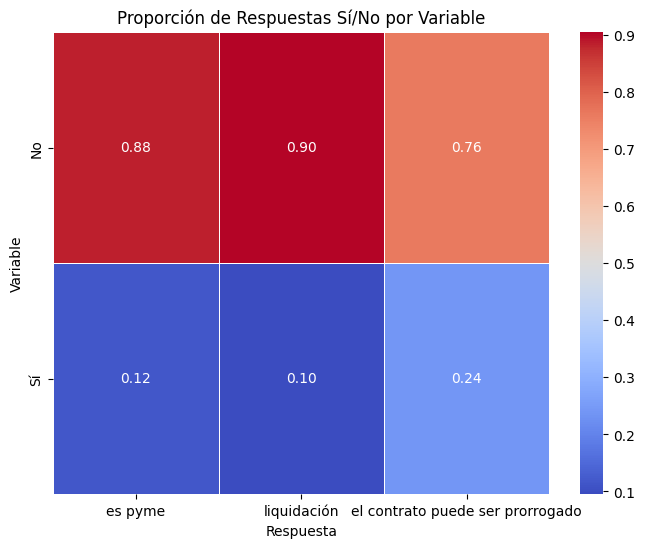

<Figure size 800x600 with 0 Axes>

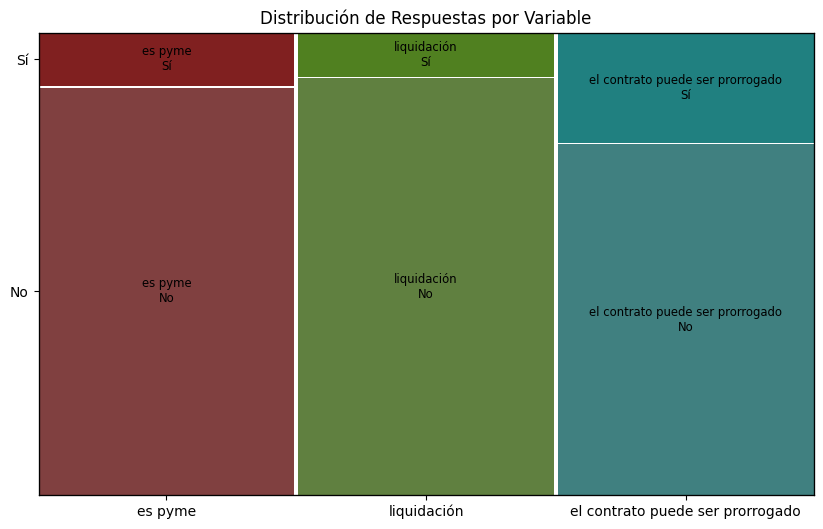

In [66]:
# Seleccionar las variables binarias
binary_vars = ["es pyme", "liquidación", "el contrato puede ser prorrogado"]

# Convertir respuestas a categóricas (asegurando que sean solo "Sí" o "No")
for col in binary_vars:
    df[col] = df[col].astype(str).str.strip().str.lower()  # Normalizar
    df[col] = df[col].map({"sí": "Sí", "si": "Sí", "no": "No"})  # Unificar respuestas

# --- Opción 1: Heatmap de proporciones ---
plt.figure(figsize=(8, 6))
heatmap_data = df[binary_vars].apply(lambda x: x.value_counts(normalize=True))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Proporción de Respuestas Sí/No por Variable")
plt.xlabel("Respuesta")
plt.ylabel("Variable")
plt.show()

# --- Opción 2: Matriz de Mosaico ---
plt.figure(figsize=(8, 6))
mosaic_data = pd.DataFrame(df[binary_vars].apply(pd.Series.value_counts).T)
mosaic_data = mosaic_data / mosaic_data.sum(axis=1).values[:, None]  # Convertir a proporciones
mosaic_dict = {(var, res): mosaic_data.loc[var, res] for var in mosaic_data.index for res in mosaic_data.columns}

fig, ax = plt.subplots(figsize=(10, 6))
mosaic(mosaic_dict, title="Distribución de Respuestas por Variable", ax=ax)
plt.show()



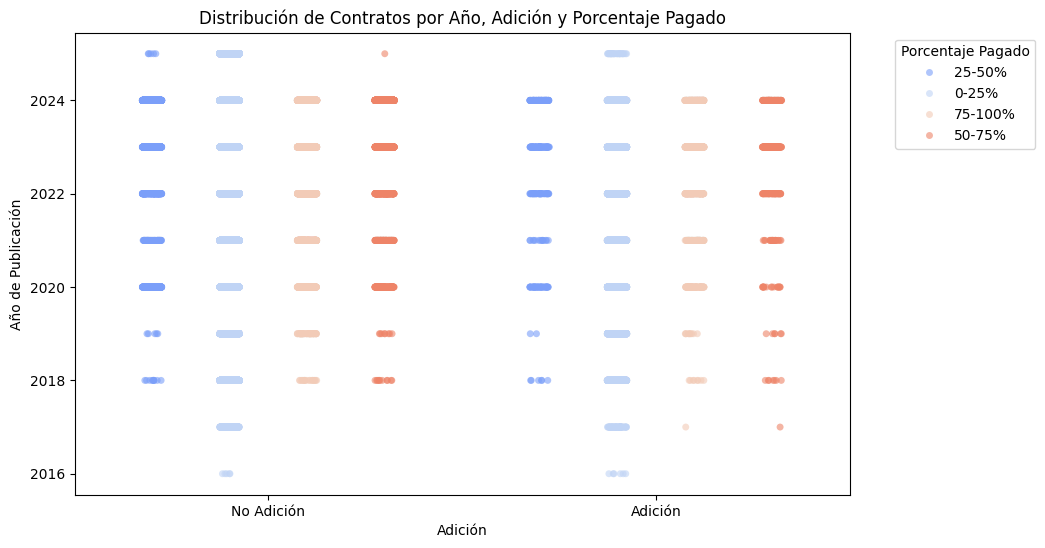

In [89]:


# --- Opción 2: Gráfico de Puntos (Dot Plot) sin modificar el DataFrame ---
plt.figure(figsize=(10, 6))
sns.stripplot(
    x="Adicion",
    y="año_publicacion",
    hue="porcentaje_pagado",  # Manteniendo la categoría original
    data=df,
    jitter=True, alpha=0.6, palette="coolwarm", dodge=True
)
plt.xlabel("Adición")
plt.ylabel("Año de Publicación")
plt.title("Distribución de Contratos por Año, Adición y Porcentaje Pagado")

plt.xticks([0, 1], ["No Adición", "Adición"])
plt.legend(title="Porcentaje Pagado", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()



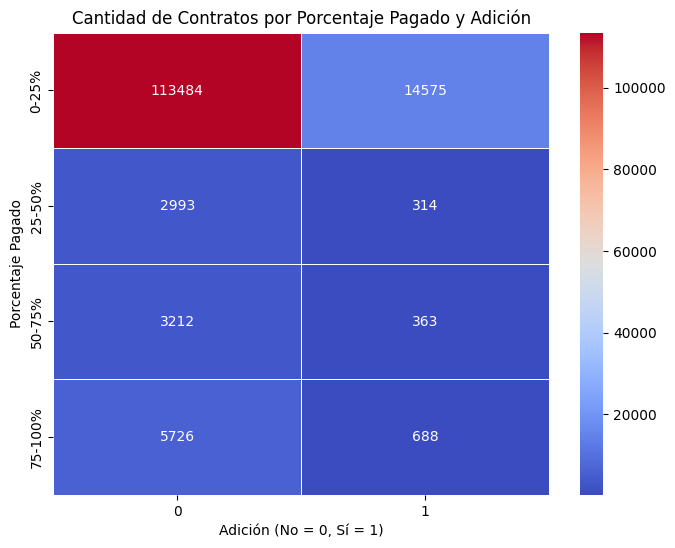

In [81]:
# Crear tabla de frecuencia con "Porcentaje Pagado" en el eje Y y "Adición" en el eje X
heatmap_data = df.pivot_table(values="año_publicacion", 
                              index="porcentaje_pagado", 
                              columns="Adicion", 
                              aggfunc="count", 
                              fill_value=0)

# Graficar el heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt="d")

# Ajustes de etiquetas
ax.set_xlabel("Adición (No = 0, Sí = 1)")
ax.set_ylabel("Porcentaje Pagado")
ax.set_title("Cantidad de Contratos por Porcentaje Pagado y Adición")

plt.show()



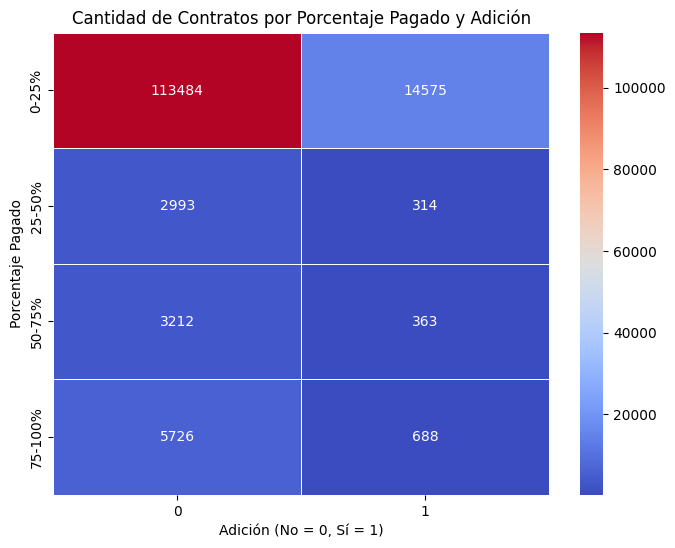

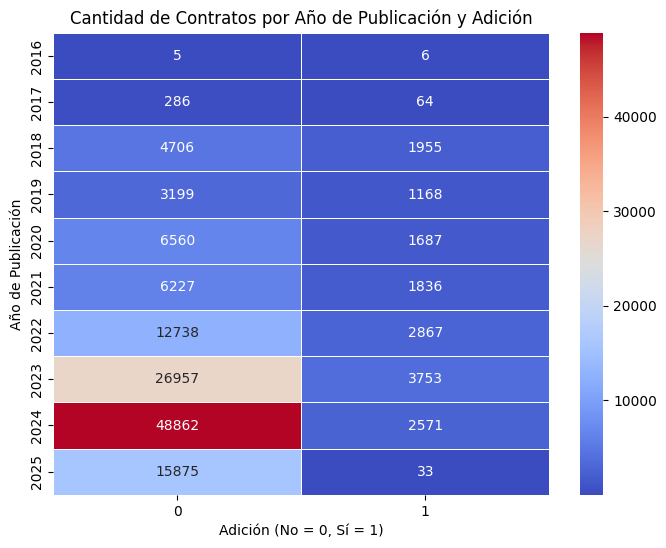

In [82]:
# --- Opción 1: Heatmap con porcentaje pagado en el eje Y y cantidad de contratos en las celdas ---
plt.figure(figsize=(8, 6))
heatmap_data = df.pivot_table(values="año_publicacion", 
                              index="porcentaje_pagado", 
                              columns="Adicion", 
                              aggfunc="count", 
                              fill_value=0)

ax = sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt="d")
ax.set_xlabel("Adición (No = 0, Sí = 1)")
ax.set_ylabel("Porcentaje Pagado")
ax.set_title("Cantidad de Contratos por Porcentaje Pagado y Adición")
plt.show()

# --- Opción 2: Heatmap con año en el eje Y y cantidad de contratos en las celdas ---
plt.figure(figsize=(8, 6))
heatmap_data = df.pivot_table(values="porcentaje_pagado", 
                              index="año_publicacion", 
                              columns="Adicion", 
                              aggfunc="count", 
                              fill_value=0)

ax = sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt="d")
ax.set_xlabel("Adición (No = 0, Sí = 1)")
ax.set_ylabel("Año de Publicación")
ax.set_title("Cantidad de Contratos por Año de Publicación y Adición")
plt.show()


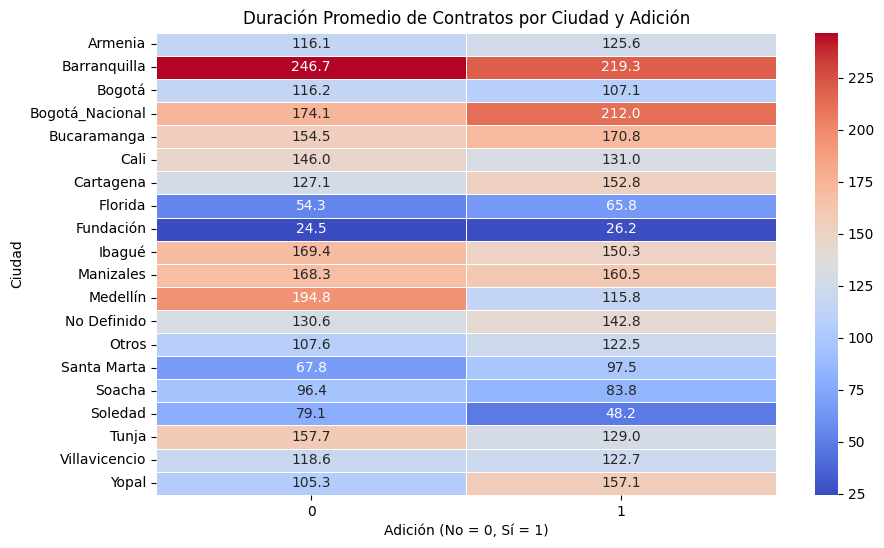

In [84]:
# Filtrar las 10 ciudades con más contratos
top_cities = df["ciudad"].value_counts().head(20).index
df_filtered = df[df["ciudad"].isin(top_cities)]

# Crear heatmap con duración promedio en días por ciudad y adición
heatmap_data = df_filtered.pivot_table(values="tiempo duracion (dias)", 
                                       index="ciudad", 
                                       columns="Adicion", 
                                       aggfunc="mean", 
                                       fill_value=0)

# Graficar el heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".1f")

# Ajustes de etiquetas
ax.set_xlabel("Adición (No = 0, Sí = 1)")
ax.set_ylabel("Ciudad")
ax.set_title("Duración Promedio de Contratos por Ciudad y Adición")

plt.show()


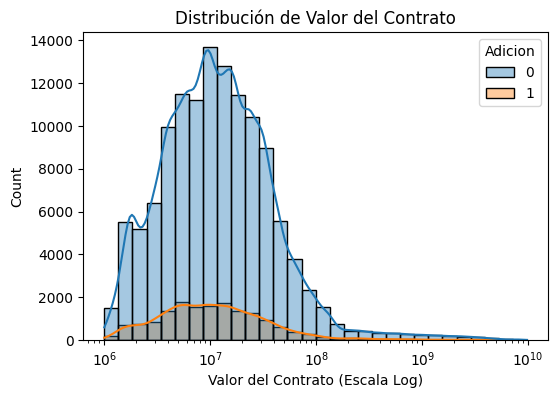

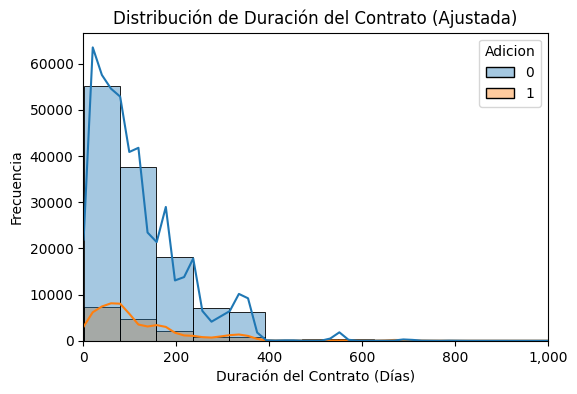

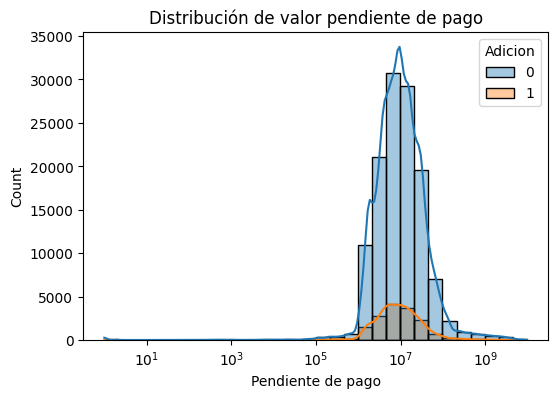

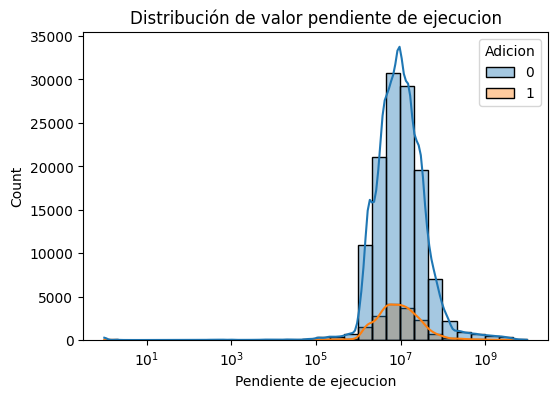

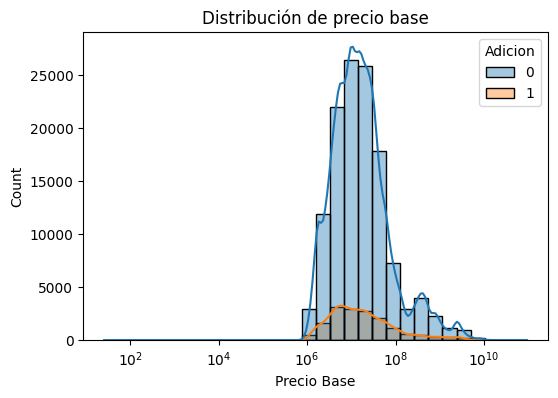

In [105]:
# Filtrar datos sin modificar el DataFrame
df_filtered = df.dropna(subset=["valor del contrato", "tiempo duracion (dias)", "porcentaje_pagado", "valor pendiente de pago","valor pendiente de ejecucion", "precio base","Adicion"])

# --- 1. Valor del contrato vs. Adición ---
plt.figure(figsize=(6, 4))
sns.histplot(df_filtered, x="valor del contrato", hue="Adicion", kde=True, bins=30, alpha=0.4, log_scale=(True, False))
plt.title("Distribución de Valor del Contrato")
plt.xlabel("Valor del Contrato (Escala Log)")
plt.show()

# Ajustar el eje X sin usar escala logarítmica, pero enfocándose en los valores más relevantes
plt.figure(figsize=(6, 4))
ax = sns.histplot(df_filtered, x="tiempo duracion (dias)", hue="Adicion", kde=True, bins=50, alpha=0.4)

# Ajustar límites del eje X para mejorar la visualización (Enfocar en valores más comunes)
ax.set_xlim(0, 1000)  # Ajustar según la distribución

# Formato del eje X sin notación científica
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

# Agregar título y etiquetas
plt.title("Distribución de Duración del Contrato (Ajustada)")
plt.xlabel("Duración del Contrato (Días)")
plt.ylabel("Frecuencia")

plt.show()


# --- 4. Pendiente vs. Adición ---
plt.figure(figsize=(6, 4))
sns.histplot(df_filtered, x="valor pendiente de pago", hue="Adicion", kde=True, bins=30, alpha=0.4, log_scale=(True, False))
plt.title("Distribución de valor pendiente de pago")
plt.xlabel("Pendiente de pago")
plt.show()


# --- 4. Pendiente vs. Adición ---
plt.figure(figsize=(6, 4))
sns.histplot(df_filtered, x="valor pendiente de ejecucion", hue="Adicion", kde=True, bins=30, alpha=0.4, log_scale=(True, False))
plt.title("Distribución de valor pendiente de ejecucion")
plt.xlabel("Pendiente de ejecucion")
plt.show()


# --- 4. Pendiente vs. Adición ---
plt.figure(figsize=(6, 4))
sns.histplot(df_filtered, x="precio base", hue="Adicion", kde=True, bins=30, alpha=0.4, log_scale=(True, False))
plt.title("Distribución de precio base")
plt.xlabel("Precio Base")
plt.show()




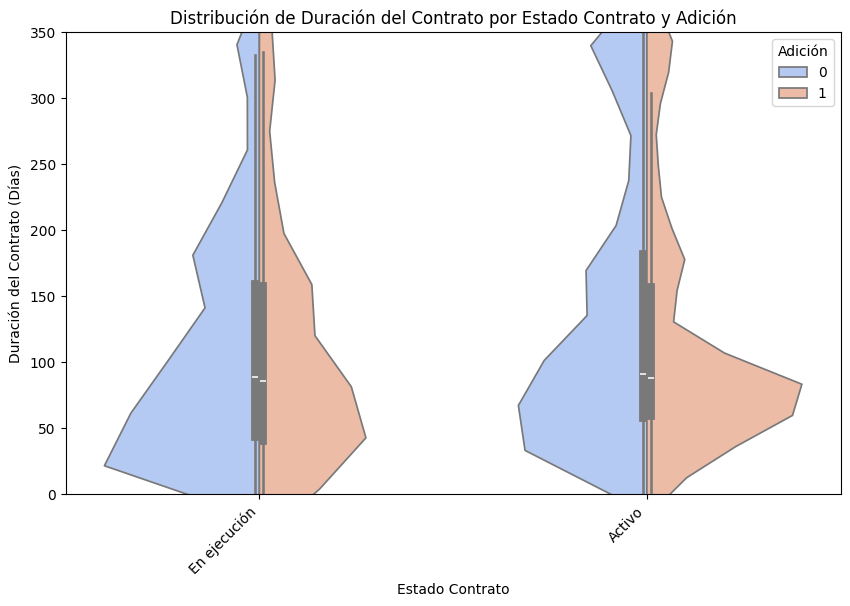

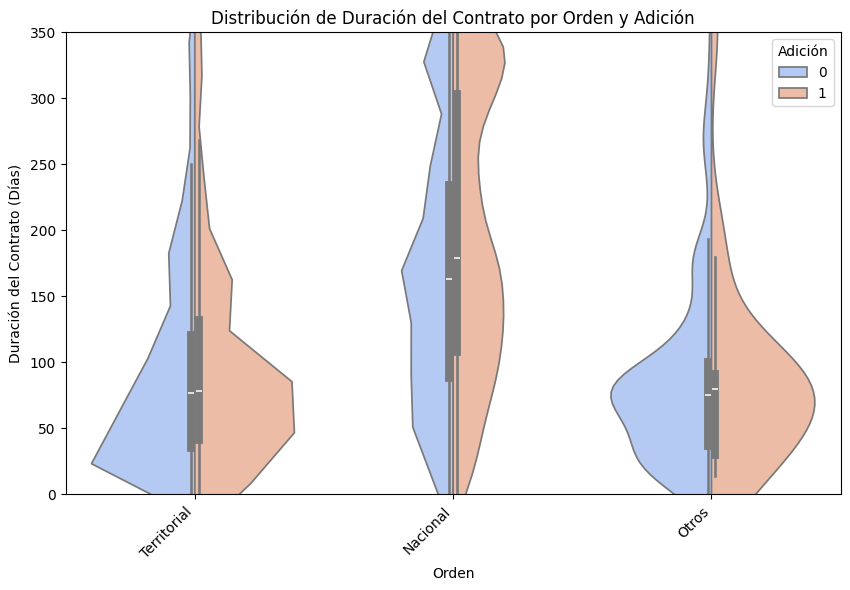

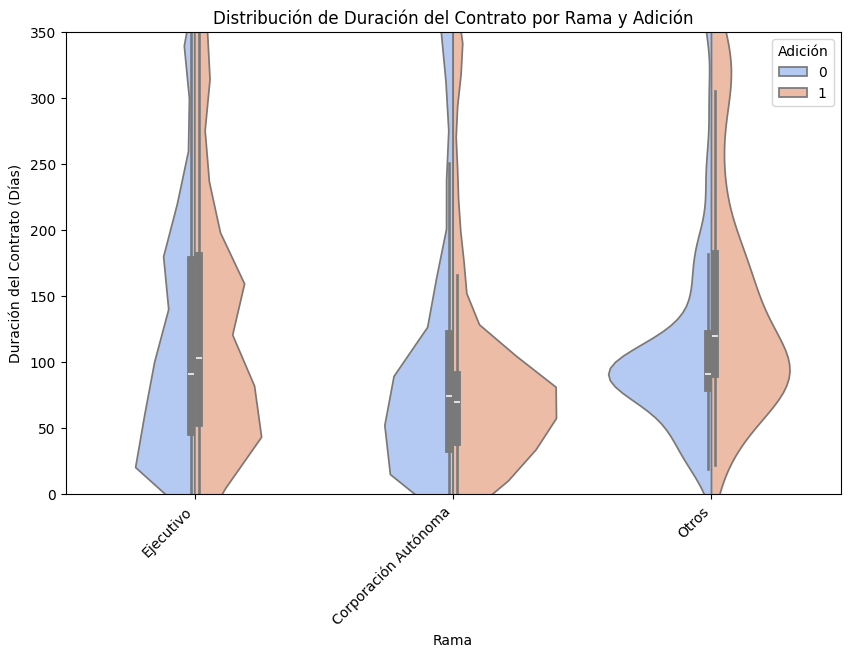

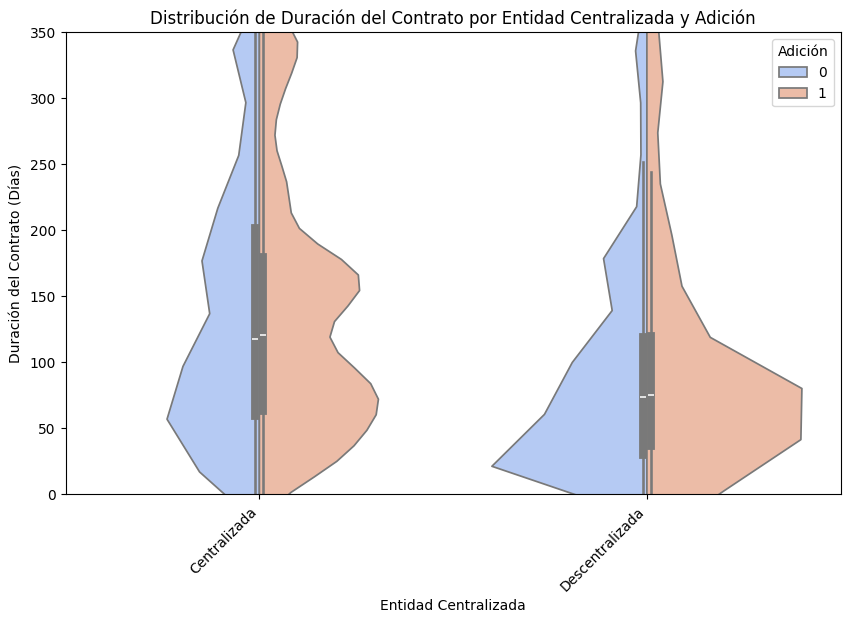

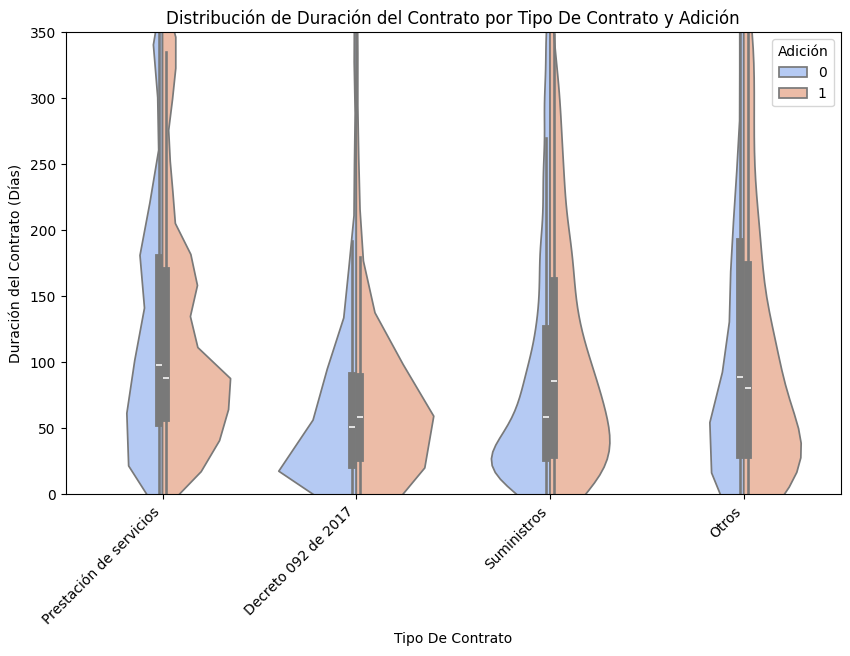

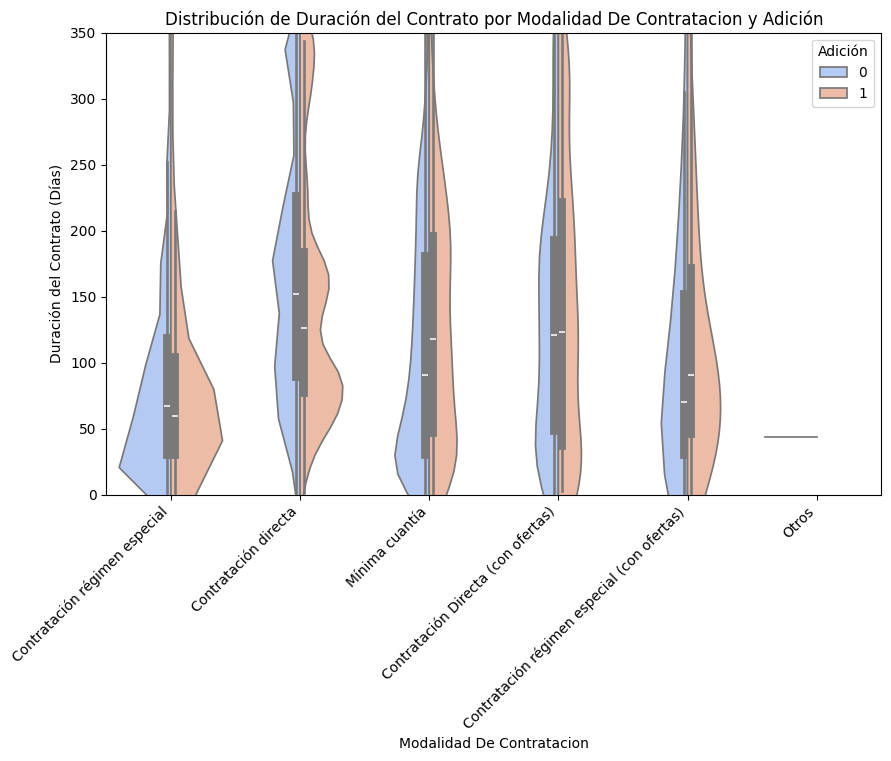

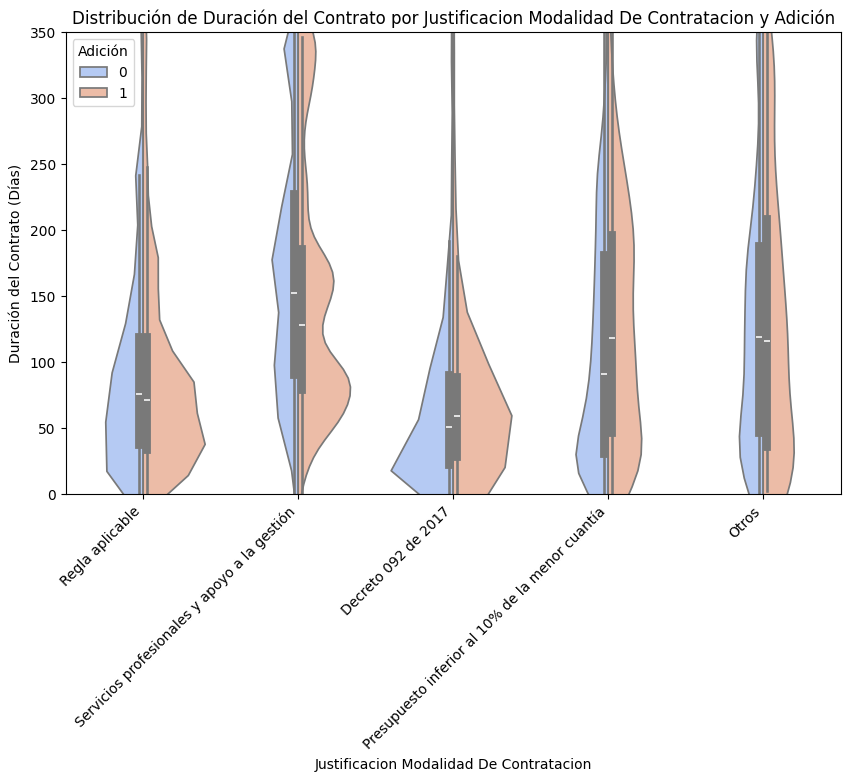

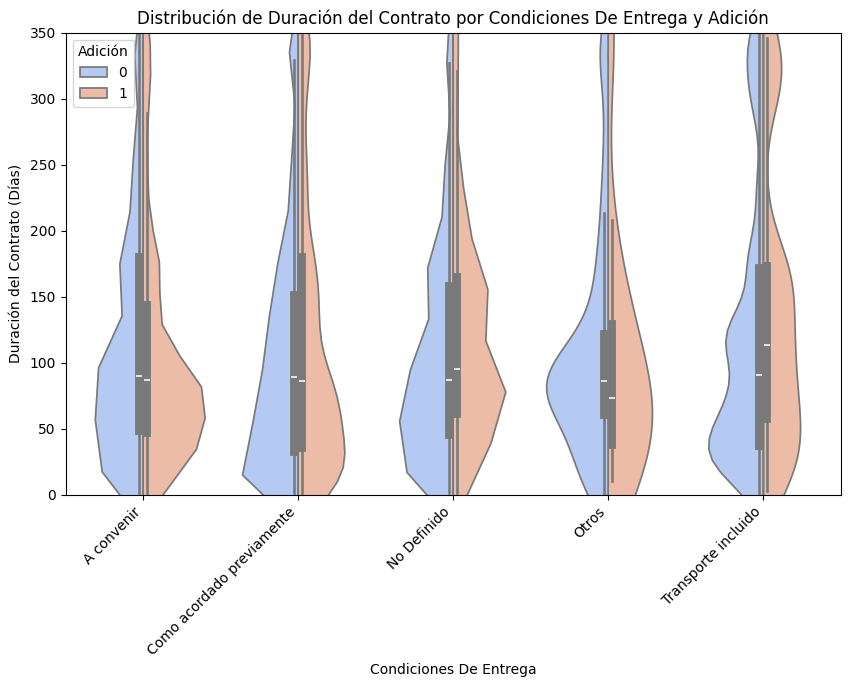

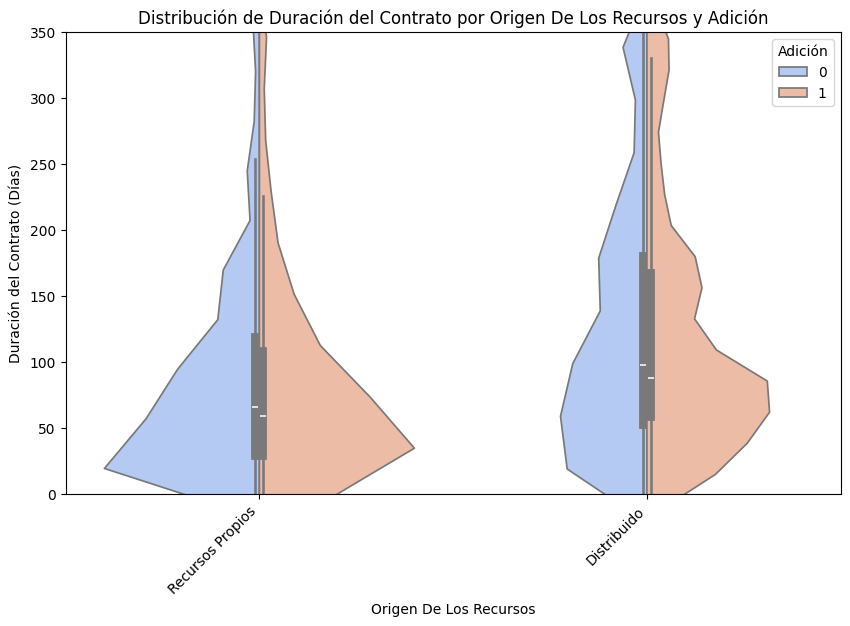

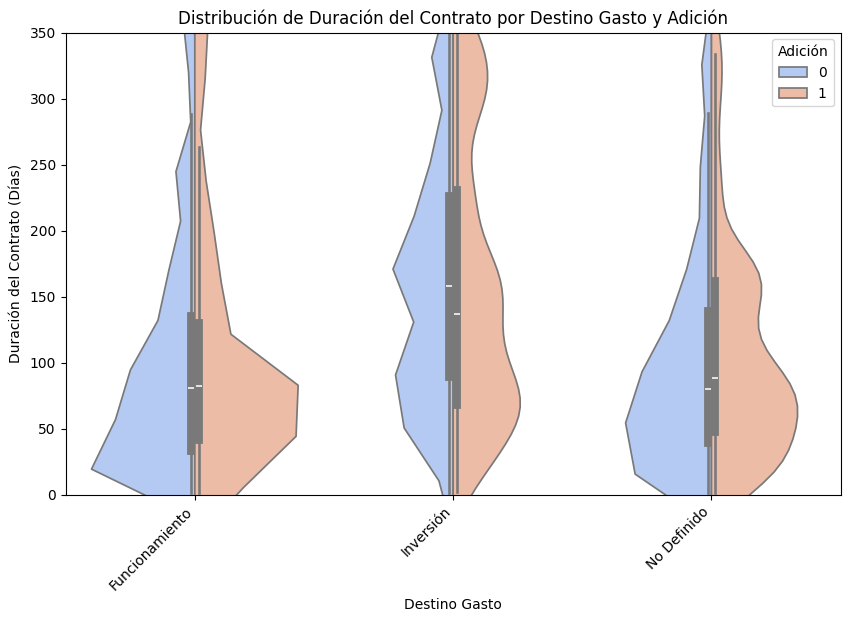

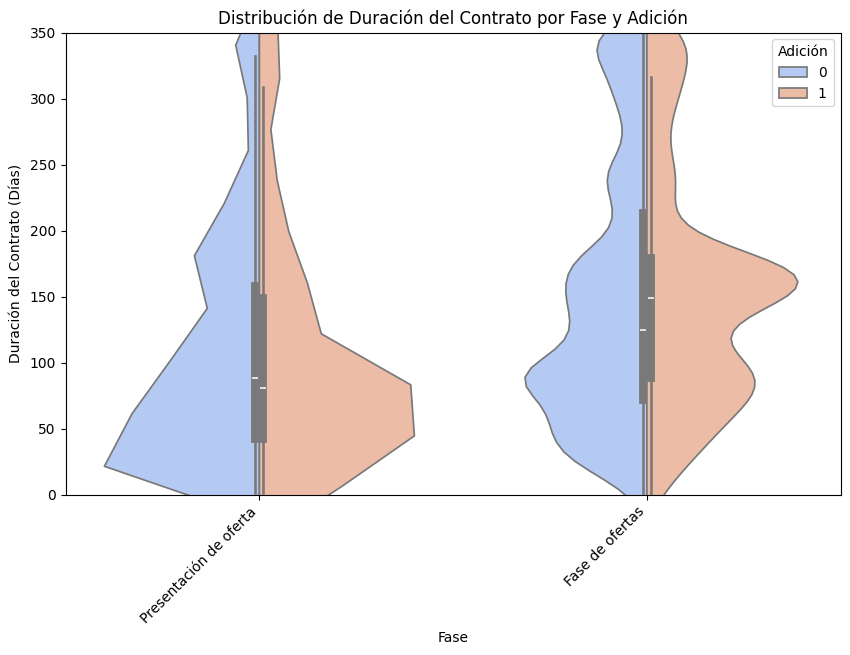

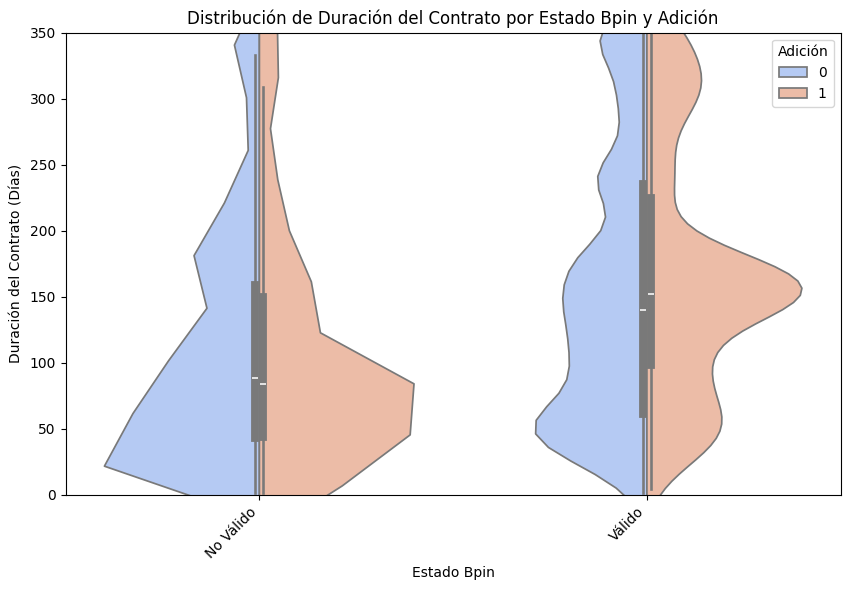

In [112]:
# Filtrar datos sin modificar el DataFrame
variables_categoricas = [
    "estado contrato", "orden", "rama", "entidad centralizada", "tipo de contrato", 
    "modalidad de contratacion", "justificacion modalidad de contratacion", 
    "condiciones de entrega", "origen de los recursos", "destino gasto", "fase","estado bpin"
]

df_filtered = df.dropna(subset=variables_categoricas + ["tiempo duracion (dias)", "Adicion"])

# Crear gráficos de violín para cada variable categórica
for var in variables_categoricas:
    plt.figure(figsize=(10, 6))
    ax = sns.violinplot(x=var, y="tiempo duracion (dias)", hue="Adicion", data=df_filtered, split=True, palette="coolwarm")
    
    # Ajustar la escala eliminando valores atípicos extremos
    ax.set_ylim(0, np.percentile(df_filtered["tiempo duracion (dias)"], 98))

    # Ajustar etiquetas
    plt.xticks(rotation=45, ha="right")
    plt.xlabel(var.replace("_", " ").title())
    plt.ylabel("Duración del Contrato (Días)")
    plt.title(f"Distribución de Duración del Contrato por {var.replace('_', ' ').title()} y Adición")
    plt.legend(title="Adición")
    plt.show()
